# 03 — Anomaly Classifier

Generate synthetic genuine/anomaly samples and train XGBoost classifier.

In [1]:
import json
import sys
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import (
    auc,
    confusion_matrix,
    f1_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tqdm import tqdm
from xgboost import XGBClassifier

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

from src.features import ALL_FEATURES

df = pd.read_csv(PROJECT_ROOT / 'data' / 'SMRT_features_v2.csv')
rt_predictor = joblib.load(PROJECT_ROOT / 'models' / 'rt_predictor.pkl')
scaler_rt = joblib.load(PROJECT_ROOT / 'models' / 'scaler.pkl')

X = df[ALL_FEATURES].values
y_rt = df['rt'].values
X_scaled = scaler_rt.transform(X)
predicted_rt_all = rt_predictor.predict(X_scaled)

rng = np.random.default_rng(42)
samples = []

for i in tqdm(range(len(df)), desc='Generating synthetic samples'):
    true_rt = y_rt[i]
    pred_rt = predicted_rt_all[i]
    features = X[i]

    # Genuine sample: ±1% noise
    noise = rng.uniform(-0.01, 0.01)
    obs_rt_genuine = true_rt * (1 + noise)
    pct_dev_genuine = abs(obs_rt_genuine - pred_rt) / pred_rt * 100 if pred_rt != 0 else 0
    if pct_dev_genuine <= 20:
        samples.append({
            **{f: features[j] for j, f in enumerate(ALL_FEATURES)},
            'observed_rt': obs_rt_genuine,
            'pct_deviation': pct_dev_genuine,
            'label': 0,
        })

    # Anomaly sample: 15-40% shift
    shift = rng.uniform(0.15, 0.40)
    obs_rt_anomaly = true_rt * (1 + shift)
    pct_dev_anomaly = abs(obs_rt_anomaly - pred_rt) / pred_rt * 100 if pred_rt != 0 else 0
    samples.append({
        **{f: features[j] for j, f in enumerate(ALL_FEATURES)},
        'observed_rt': obs_rt_anomaly,
        'pct_deviation': pct_dev_anomaly,
        'label': 1,
    })

synth_df = pd.DataFrame(samples)
print(f'Total samples: {len(synth_df)}')
print(synth_df['label'].value_counts())

Generating synthetic samples: 100%|██████████| 77901/77901 [00:04<00:00, 19010.29it/s]


Total samples: 153446
label
1    77901
0    75545
Name: count, dtype: int64


In [2]:
CLASSIFIER_FEATURES = ALL_FEATURES + ['observed_rt', 'pct_deviation']

X_clf = synth_df[CLASSIFIER_FEATURES].values
y_clf = synth_df['label'].values

X_train, X_test, y_train, y_test = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)

scaler_clf = StandardScaler()
X_train_scaled = scaler_clf.fit_transform(X_train)
X_test_scaled = scaler_clf.transform(X_test)

clf = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    eval_metric='auc',
)
clf.fit(X_train_scaled, y_train)

y_proba = clf.predict_proba(X_test_scaled)[:, 1]
fpr_curve, tpr_curve, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr_curve, tpr_curve)
print(f'AUC: {roc_auc:.4f}')

AUC: 0.9799


In [3]:
thresholds = [0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60]
threshold_results = []

for thresh in thresholds:
    y_pred = (y_proba >= thresh).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    detection_rate = tp / (tp + fn) if (tp + fn) > 0 else 0
    fpr_val = fp / (fp + tn) if (fp + tn) > 0 else 0
    f1 = f1_score(y_test, y_pred)
    threshold_results.append({
        'Threshold': thresh,
        'Detection Rate (%)': detection_rate * 100,
        'FPR (%)': fpr_val * 100,
        'F1': f1,
    })

thresh_df = pd.DataFrame(threshold_results)
print(thresh_df.to_string(index=False))

selected_threshold = 0.50
y_pred_final = (y_proba >= selected_threshold).astype(int)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_final).ravel()
detection_rate = tp / (tp + fn)
fpr_val = fp / (fp + tn)
f1_final = f1_score(y_test, y_pred_final)
print(f'\nSelected threshold={selected_threshold}: F1={f1_final:.4f}, Detection={detection_rate*100:.1f}%, FPR={fpr_val*100:.1f}%')

 Threshold  Detection Rate (%)  FPR (%)       F1
      0.30           94.358514 9.332186 0.927776
      0.35           93.768051 7.915812 0.930959
      0.40           93.132662 6.697995 0.933063
      0.45           92.323984 5.698590 0.933273
      0.50           91.585906 4.871269 0.933076
      0.55           90.854246 4.262360 0.931898
      0.60           89.955715 3.607122 0.929998

Selected threshold=0.5: F1=0.9331, Detection=91.6%, FPR=4.9%


In [4]:
# Sensitivity analysis: RT shifts of 2%, 5%, 8%, 15%
shift_levels = [0.02, 0.05, 0.08, 0.15]
sensitivity_results = []

test_indices = np.random.default_rng(42).choice(len(df), size=min(5000, len(df)), replace=False)

for shift in shift_levels:
    detected = 0
    for idx in test_indices:
        features = X[idx]
        pred_rt = predicted_rt_all[idx]
        obs_rt = y_rt[idx] * (1 + shift)
        pct_dev = abs(obs_rt - pred_rt) / pred_rt * 100 if pred_rt != 0 else 0
        clf_input = np.hstack([features, [obs_rt, pct_dev]]).reshape(1, -1)
        prob = clf.predict_proba(scaler_clf.transform(clf_input))[0, 1]
        if prob >= selected_threshold:
            detected += 1
    rate = detected / len(test_indices) * 100
    sensitivity_results.append({'RT Shift': f'{shift*100:.0f}%', 'Detection Rate (%)': rate})

sens_df = pd.DataFrame(sensitivity_results)
print(sens_df.to_string(index=False))

RT Shift  Detection Rate (%)
      2%                9.28
      5%               16.08
      8%               28.56
     15%               67.50


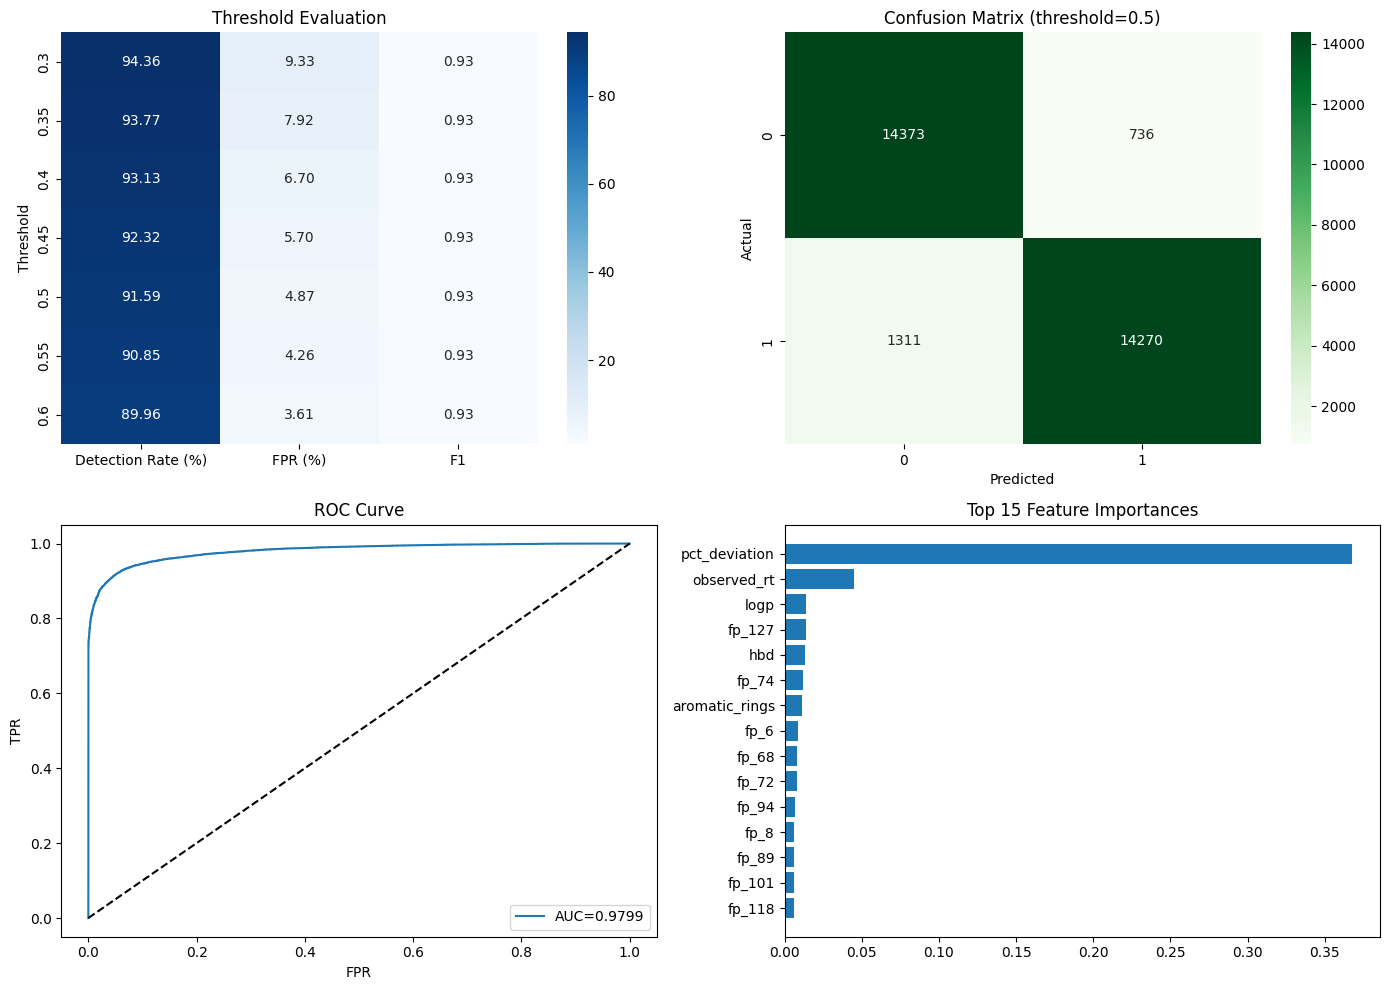

Top feature: pct_deviation


In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.heatmap(thresh_df.set_index('Threshold')[['Detection Rate (%)', 'FPR (%)', 'F1']],
            annot=True, fmt='.2f', ax=axes[0, 0], cmap='Blues')
axes[0, 0].set_title('Threshold Evaluation')

cm = confusion_matrix(y_test, y_pred_final)
sns.heatmap(cm, annot=True, fmt='d', ax=axes[0, 1], cmap='Greens')
axes[0, 1].set_xlabel('Predicted')
axes[0, 1].set_ylabel('Actual')
axes[0, 1].set_title(f'Confusion Matrix (threshold={selected_threshold})')

axes[1, 0].plot(fpr_curve, tpr_curve, label=f'AUC={roc_auc:.4f}')
axes[1, 0].plot([0, 1], [0, 1], 'k--')
axes[1, 0].set_xlabel('FPR')
axes[1, 0].set_ylabel('TPR')
axes[1, 0].set_title('ROC Curve')
axes[1, 0].legend()

importances = clf.feature_importances_
feat_names = CLASSIFIER_FEATURES
top_idx = np.argsort(importances)[-15:]
axes[1, 1].barh([feat_names[i] for i in top_idx], importances[top_idx])
axes[1, 1].set_title('Top 15 Feature Importances')

plt.tight_layout()
plt.show()

top_feat = feat_names[np.argmax(importances)]
print(f'Top feature: {top_feat}')

In [6]:
models_dir = PROJECT_ROOT / 'models'
joblib.dump(clf, models_dir / 'anomaly_classifier.pkl')
joblib.dump(scaler_clf, models_dir / 'scaler_classifier.pkl')

classifier_info = {
    'auc': round(float(roc_auc), 4),
    'f1': round(float(f1_final), 4),
    'threshold': selected_threshold,
    'detection_rate': round(float(detection_rate), 3),
    'fpr': round(float(fpr_val), 3),
    'feature_count': 139,
    'rt_feature_count': 137,
    'model_version': 'v4',
    'rt_predictor_r2': 0.77,
}

with open(models_dir / 'classifier_info.json', 'w', encoding='utf-8') as f:
    json.dump(classifier_info, f, indent=2)

print('Saved anomaly_classifier.pkl, scaler_classifier.pkl, classifier_info.json')

Saved anomaly_classifier.pkl, scaler_classifier.pkl, classifier_info.json
